### Data preparation example
This notebook prepares the datasets used by the downscaling workflow (`01_woodville_downscaling.ipynb`).

Note: the downscaling notebook downloads these prepared datasets directly, so running this notebook is not required.

We download three input datasets, which would typically be provided by the user, and derive the other datasets.
- Input datasets:
    - High-resolution digital elevation model (DEM)
    - River flowlines and catchments
    - Ponded water depth mesh
- Derived datasets:
    - Mesh cell slope detrended DEM
    - Retraced river flowlines on hi-res DEM
    - River segment catchments for the retraced flowlines
    - Height Above Nearest Drainage (HAND)
    - Raster mapping mesh cells to DEM pixels

First, set up a Python environment to use as this notebook's kernel:
```bash
conda create -n dd-env python=3.12 --yes
conda activate dd-env
pip install git+https://github.com/passaH2O/depth-downscaler.git
pip install "depth-downscaler[examples]"
```

In [1]:
import geopandas as gpd
import depth_downscaler as dd
import matplotlib.pyplot as plt
import rasterio as rio

from pathlib import Path
from rasterio.plot import plotting_extent

We download the input data:
- `woodville_mesh.gpkg`: ponded water mesh
- `woodville_usgs1m.tif`: DEM
- `fl.gpkg`: river flowlines
- `catch.gpkg`: catchments


In [2]:
!curl https://utexas.box.com/shared/static/4839qusz2hhm8xhscr57kbyj470cuy1s.gpkg -Lso woodville_mesh.gpkg
!curl https://utexas.box.com/shared/static/p0o0yfo1brzpoy8dqynl2dv2ht7s343b.tif  -Lso woodville_usgs1m.tif
!curl https://utexas.box.com/shared/static/8xkxf3t0pc5xnrlb4auwkrltcktv07pc.gpkg -Lso fl.gpkg
!curl https://utexas.box.com/shared/static/1k4dngc7vaucb4t2y2cpdoqur2nv5gjm.gpkg -Lso catch.gpkg

In [3]:
pw_mesh_path = "woodville_mesh.gpkg"
dem_path = "woodville_usgs1m.tif"
flowline_path = "fl.gpkg"
catchment_path = "catch.gpkg"

The flowlines and catchments correspond to four NHDPlusV2 COMIDs that drain our study area. All datasets have UTM 15N projected coordinates (EPSG:26915). The DEM is provided by USGS at 1 m resolution. We cropped the DEM to a 500 m buffer around the catchments. Visualizing the DEM, NHDPlusV2 flowlines, and catchments:

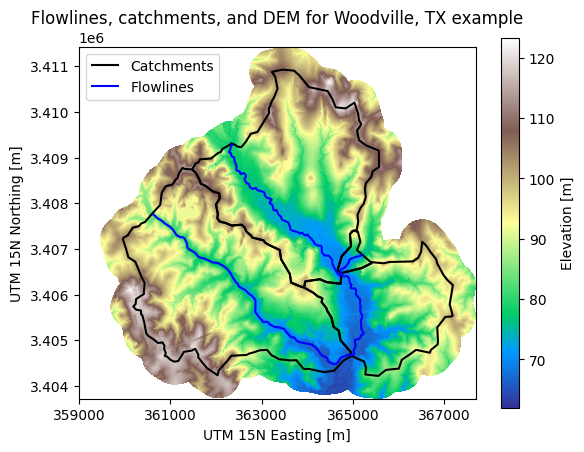

In [4]:
catchments = gpd.read_file(catchment_path)
flowlines = gpd.read_file(flowline_path)

with rio.open(dem_path) as src:
    dem = src.read(1, masked=True)
    dem_extent = plotting_extent(src)

fig, ax = plt.subplots()
catchments.boundary.plot(ax=ax, color="black", label="Catchments")
flowlines.plot(ax=ax, color="blue", label="Flowlines")
im = ax.imshow(
    dem,
    cmap="terrain",
    extent=dem_extent,
    interpolation="nearest",
    resample=False,
)
ax.set(
    title="Flowlines, catchments, and DEM for Woodville, TX example",
    xlabel="UTM 15N Easting [m]",
    ylabel="UTM 15N Northing [m]",
    xticks=ax.get_xticks()[::2],  # fix overlapping x ticks
)
ax.legend(loc="upper left")
plt.colorbar(im, ax=ax, label="Elevation [m]")
plt.show()

We use depth-downscaler to obtain a per-mesh-cell elevation detrended DEM

In [5]:
# detrend DEM (also writes the mesh cell IDs raster)
dd.detrend(
    dem_path=dem_path,
    mesh_path=pw_mesh_path,
    out_detrend_path="woodville_detrended.tif",
)

Detrended DEM written to woodville_detrended.tif
polygon IDs written to woodville_detrended_cellids.tif


Next we use pyGeoFlood:
- Retrace NHDPlusV2 flowlines on the 1m DEM
- Delineate catchments for 1 to 1.5 km segments of the retraced flowlines
    - These datasets are required to compute HAND and for the later downscaling workflow

In [6]:
from pygeoflood import pyGeoFlood

# make a directory to hold pyGeoFlood outputs
temp_dir = Path("temp_outputs")
temp_dir.mkdir(exist_ok=True)

pgf = pyGeoFlood(dem_path=dem_path, project_dir=temp_dir)
pgf.flowline_path = flowline_path
pgf.catchment_path = catchment_path
pgf.run_ce_workflow()  # run the river channel extraction workflow
pgf.segment_channel_network()  # divide the extracted river channel network into 1 to 1.5 km segments
pgf.delineate_segment_catchments()  # delineate catchments for each segment
pgf.vectorize_segment_catchments()  # convert the segment catchments from raster to vector format

Running apply_nonlinear_filter with parameters:
    custom_dem = None
    custom_path = None
    method = PeronaMalik2
    smoothing_quantile = 0.9
    time_increment = 0.1
    n_iter = 50
    sigma_squared = 0.05
Computing slope of raw DTM
DEM slope array shape: (7705, 8228)
Computing lambda = q-q-based nonlinear filtering threshold
DEM smoothing Quantile: 0.9
Edge Threshold Value: 0.16041257798671726
Filtered DEM written to temp_outputs/woodville_usgs1m_filtered.tif
apply_nonlinear_filter completed in 56.9708 seconds

Running calculate_slope with parameters:
    custom_filtered_dem = None
    custom_path = None
 slope statistics
 min angle: 0.0
 max angle: 39.38961
 mean slope: 0.06723727
 stdev slope: 0.07125096
Slope raster written to temp_outputs/woodville_usgs1m_slope.tif
calculate_slope completed in 3.5316 seconds

Running calculate_curvature with parameters:
    custom_filtered_dem = None
    custom_path = None
    method = geometric
 using geometric curvature
 curvature statis

Next we calculate HAND.
- First compile TauDEM following this fork's README: https://github.com/markwang0/TauDEM
- Then calculate HAND by running TauDEM with the `bash` commands below

In [7]:
# first we write a script to run the TauDEM commands
taudem_commands = """#!/bin/bash
set -x  # print each command before executing
num_proc=$(( $(nproc) - 1 ))  # use all but one core

# positional args
dem_name="${1}"
temp_dir="${2}"

### TauDEM commands to obtain Dinf HAND raster

# remove pits from DEM --> filled elevation (_fel.tif)
mpiexec -n ${num_proc} pitremove \\
            -z ${dem_name}.tif \\
            -fel ${temp_dir}/${dem_name}_fel.tif

# calculate Dinf flow direction and slope (_ang.tif and _slp.tif)
mpiexec -n ${num_proc} dinfflowdir \\
            -fel ${temp_dir}/${dem_name}_fel.tif \\
            -ang ${temp_dir}/${dem_name}_ang.tif \\
            -slp ${temp_dir}/${dem_name}_slp.tif

# calculate HAND with filled elev, Dinf, and pyGeoFlood extracted channels as inputs
mpiexec -n ${num_proc} dinfdistdown \\
            -fel ${temp_dir}/${dem_name}_fel.tif \\
            -ang ${temp_dir}/${dem_name}_ang.tif \\
            -slp ${temp_dir}/${dem_name}_slp.tif \\
            -src ${temp_dir}/${dem_name}_channel_network_raster.tif \\
            -dd ${dem_name}_HAND_taudem.tif \\
            -m ave v
"""

Path("run_taudem.sh").write_text(taudem_commands)

1052

In [8]:
# pass the DEM stem (woodville_usgs1m) and the temp directory (temp_outputs) to the TauDEM script
!bash run_taudem.sh {Path(dem_path).stem} {temp_dir}

++ nproc
+ num_proc=7
+ dem_name=woodville_usgs1m
+ temp_dir=temp_outputs
+ mpiexec -n 7 pitremove -z woodville_usgs1m.tif -fel temp_outputs/woodville_usgs1m_fel.tif
PitRemove version 5.3.9
Input file woodville_usgs1m.tif has projected coordinate system.
Nodata value input to create partition from file: -999999.000000
Nodata value recast to float used in partition raster: -999999.000000
This run may take on the order of 2 minutes to complete.
This estimate is very approximate. 
Run time is highly uncertain as it depends on the complexity of the input data 
and speed and memory of the computer. This estimate is based on our testing on 
a dual quad core Dell Xeon E5405 2.0GHz PC with 16GB RAM.
Processes: 7
Header read time: 0.080162
Data read time: 0.143977
Compute time: 4.539997
Write time: 1.238840
Total time: 6.002976
+ mpiexec -n 7 dinfflowdir -fel temp_outputs/woodville_usgs1m_fel.tif -ang temp_outputs/woodville_usgs1m_ang.tif -slp temp_outputs/woodville_usgs1m_slp.tif
DinfFlowDir v

Finally, we clean up:
- Convert and save the outputs we will use in the downscaling notebook
- Removing the temporary outputs directory

In [9]:
gpd.read_file(pgf.segmented_channel_network_path).to_file("woodville_retraced_fl_segments.gpkg")
gpd.read_file(pgf.segment_catchments_vector_path).to_file("woodville_segment_catchments.gpkg")

In [10]:
!rm -r temp_outputs

Next we run the downscaling workflow in `01_woodville_downscaling.ipynb`.

- Note: the data prepared in this notebook is downloaded directly in the downscaling notebook, so running this notebook is not required.
